## Imports

In [1]:
import string

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerPatch
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
import numpy as np

from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR
from analysis_helpers.functions import (
    dtw, 
    mean_center, 
    rankbiserialr,
    show_source
)

## Functions

In [2]:
show_source(dtw)

In [3]:
show_source(mean_center)

In [4]:
show_source(rankbiserialr)

In [5]:
def blend_white(color, amount):
    """
    Blend a color toward white (lighten + desaturate) by an `amount` in 
    [0, 1].
    """
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1.0 - rgb) * amount)

In [6]:
def draw_dtw_matches(ax, path_front, path_back, warp_ixs):
    """
    Draw lines connecting DTW-matched pairs of events between two paths.
    """
    for front_idx, back_idx in warp_ixs:
        ax.plot([path_front[front_idx, 0], path_back[back_idx, 0]],
                [path_front[front_idx, 1], path_back[back_idx, 1]],
                color=WARP_LINE_COLOR, 
                alpha=WARP_LINE_ALPHA, 
                lw=WARP_LINEWIDTH,
                zorder=1, 
                solid_capstyle="round")

In [7]:
def draw_event_path(ax, path, color, back=False):
    """
    Draw one event path (front or back) for a 2D trajectory comparison 
    panel. 
    """
    if back:
        path = path + DEPTH_OFFSET
        color = blend_white(color, BACK_LIGHTEN)
        lw = PATH_LINEWIDTH * BACK_LW_SCALE
        casing = lw + BACK_CASING_EXTRA
        markersize = EVENT_MARKERSIZE * BACK_MARKER_SCALE
        zorder_line = 2.0
        zorder_dots = 2.6
        effects = []
    else:
        lw = PATH_LINEWIDTH
        casing = PATH_CASING_WIDTH
        markersize = EVENT_MARKERSIZE
        zorder_line = 4.0
        zorder_dots = 6.0
        effects = [pe.SimpleLineShadow(offset=SHADOW_OFFSET, 
                                       shadow_color=SHADOW_COLOR, 
                                       alpha=SHADOW_ALPHA, 
                                       rho=1.0)]
    
    effects.extend([pe.Stroke(linewidth=casing, foreground="white"), 
                    pe.Normal()])
    ax.plot(path[:, 0], 
            path[:, 1], 
            "-", 
            color=color, 
            lw=lw, 
            zorder=zorder_line,
            solid_capstyle="round", 
            solid_joinstyle="round", 
            path_effects=effects)
    ax.scatter(path[:, 0], 
               path[:, 1], 
               s=markersize, 
               color=color, 
               zorder=zorder_dots,
               edgecolor="white", 
               linewidth=EVENT_BORDER_WIDTH)
    return ax

In [8]:
def draw_offset_indicator(ax):
    """
    Draw small arrow showing the magnitude & direction of the x,y offset 
    applied to the back path for visualization.
    """
    span = max(TRAJ2D_XMAX - TRAJ2D_XMIN, TRAJ2D_YMAX - TRAJ2D_YMIN)
    margin = 0.07 * span
    head = np.array([TRAJ2D_XMAX - margin, TRAJ2D_YMIN + margin])
    tail = head - DEPTH_OFFSET
    ax.annotate("", 
                xy=tuple(head), 
                xytext=tuple(tail),
                arrowprops={'arrowstyle': OFFSET_INDICATOR_ARROW_STYLE,
                            'color': OFFSET_INDICATOR_COLOR, 
                            'lw': OFFSET_INDICATOR_ARROW_LW,
                            'shrinkA': 0,
                            'shrinkB': 0},
                zorder=8)
    ax.scatter(*tail, 
               s=OFFSET_INDICATOR_DOT_SIZE, 
               color=OFFSET_INDICATOR_COLOR, 
               edgecolor="white",
               linewidth=0.8, 
               zorder=8)
    return ax

In [9]:
def draw_traj2d_panel(
    ax, 
    front_path, 
    back_path, 
    front_color, 
    back_color, 
    warp_ixs, 
    warp_cost,
    title
):
    """Draw a 2D trajectory comparison panel in full"""
    draw_dtw_matches(ax, front_path, back_path + DEPTH_OFFSET, warp_ixs)
    draw_event_path(ax, back_path, back_color, back=True)
    draw_event_path(ax, front_path, front_color)
    draw_offset_indicator(ax)
    
    ax.set_xlim(TRAJ2D_XMIN, TRAJ2D_XMAX)
    ax.set_ylim(TRAJ2D_YMIN, TRAJ2D_YMAX)
    ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(title, 
                 loc='center', 
                 fontsize=TRAJ_TITLE_FONTSIZE, 
                 pad=TRAJ_TITLE_PAD)
    ax.text(WARP_COST_BOX_X, 
            WARP_COST_BOX_Y, 
            f'warp cost = {warp_cost:.3f}',
            transform=ax.transAxes, 
            ha="left", 
            va="top", 
            fontsize=WARP_COST_BOX_FONTSIZE,
            bbox=WARP_COST_BBOX_STYLE)
    return ax

In [10]:
def draw_slope_panel(
    ax, 
    left_costs, 
    right_costs, 
    left_color, 
    right_color, 
    left_label,
    right_label
):
    """Draw a slope plot comparing two sets of per-participant warp costs"""
    x_left, x_right = SLOPE_X
    for a, b in zip(left_costs, right_costs):
        ax.plot([x_left, x_right], 
                [a, b], 
                color=CONNECTOR_COLOR, 
                alpha=CONNECTOR_ALPHA,
                lw=CONNECTOR_LW, 
                zorder=1, 
                solid_capstyle='round')
    
    for x, costs in ((x_left, left_costs), (x_right, right_costs)):
        mean = costs.mean()
        ax.plot([x - MEAN_TICK_HALFWIDTH, 
                 x + MEAN_TICK_HALFWIDTH], 
                [mean, mean],
                color=MEAN_TICK_COLOR, 
                lw=MEAN_TICK_LW, 
                solid_capstyle='round', 
                zorder=3)
    
    ax.scatter(np.full_like(left_costs, x_left), 
               left_costs, 
               s=SLOPE_DOT_SIZE, 
               c=left_color,
               edgecolors='white', 
               linewidths=SLOPE_DOT_EDGE_W, 
               zorder=5)
    ax.scatter(np.full_like(right_costs, x_right), 
               right_costs, 
               s=SLOPE_DOT_SIZE, 
               c=right_color,
               edgecolors='white', 
               linewidths=SLOPE_DOT_EDGE_W, 
               zorder=5)
    ax.set_ylim(*SLOPE_YLIM)
    ax.set_xlim(x_left - SLOPE_XPAD, x_right + SLOPE_XPAD)
    ax.set_xticks([x_left, x_right])
    ax.set_xticklabels([left_label, right_label])
    ax.set_ylabel('Warp cost')
    ax.spines[['top', 'right']].set_visible(False)
    return ax

In [11]:
def draw_dumbbell_panel(
    ax, 
    own_costs, 
    other_costs, 
    plot_order, 
    own_label, 
    accent_color
):
    """
    Draw an own-vs-median-others dumbbell plot for one of the two 
    surrogate analyses
    """
    for row, i in enumerate(plot_order):
        y = len(participants) - 1 - row
        median_others = np.median(other_costs[i])
        ax.plot([median_others, own_costs[i]], 
                [y, y], 
                color=CONNECTOR_COLOR,
                alpha=CONNECTOR_ALPHA, 
                lw=CONNECTOR_LW, 
                zorder=1)
        ax.scatter(median_others, 
                   y, 
                   s=DUMBBELL_MEDIAN_DOT_SIZE, 
                   c=SURROGATE_COLOR, 
                   zorder=2)
        ax.scatter(own_costs[i], 
                   y, 
                   s=DUMBBELL_OWN_DOT_SIZE, 
                   c=accent_color,
                   edgecolors='w', 
                   linewidths=DUMBBELL_OWN_EDGE_W, 
                   zorder=3)
    
    ax.set_xlabel('Warp cost')
    ax.set_ylabel('Participants')
    ax.set_ylim(-1, len(participants))
    ax.set_yticks([])
    ax.set_xlim(*DUMBBELL_XLIM)
    ax.invert_xaxis()
    
    own_handle = Line2D([], 
                        [], 
                        marker='o', 
                        color=accent_color, 
                        linestyle='None', 
                        markersize=DUMBBELL_LEGEND_MARKERSIZE, 
                        label=own_label)
    others_handle = Line2D([], 
                           [], 
                           marker='o', 
                           color=SURROGATE_COLOR, 
                           linestyle='None', 
                           markersize=DUMBBELL_LEGEND_MARKERSIZE, 
                           label='Median others')
    ax.legend(handles=[own_handle, others_handle], 
              loc='lower right', 
              bbox_to_anchor=(1, 0),
              fontsize=DUMBBELL_LEGEND_FONTSIZE, 
              frameon=False,
              handletextpad=0.5, 
              labelspacing=0.5)
    
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_box_aspect(QUANT_BOX_ASPECT)
    return ax

In [12]:
def draw_topk_panel(ax, own_costs, others_costs, accent_color):
    """
    Draw a top-k identification accuracy curve for one of the two 
    surrogate analyses
    """
    ks = np.arange(1, len(own_costs) + 1)
    chance = np.arange(1, len(own_costs) + 1) / len(own_costs)
    n_below = (others_costs < own_costs[:, None]).sum(axis=1)
    n_tied  = (others_costs == own_costs[:, None]).sum(axis=1)
    survival_rate = np.array([
        np.mean(np.clip(k - n_below, 0, n_tied + 1) / (n_tied + 1)) for k in ks
    ])
    
    ax.fill_between(ks, 
                    chance, 
                    survival_rate, 
                    color=accent_color, 
                    alpha=TOPK_FILL_ALPHA, 
                    zorder=1)
    ax.plot(ks, 
            survival_rate, 
            color=accent_color, 
            lw=TOPK_LINE_WIDTH, 
            zorder=3, 
            label='Observed')
    ax.plot(ks, 
            chance, 
            color=SURROGATE_COLOR, 
            lw=CHANCE_LINE_WIDTH, 
            ls='--', 
            zorder=2, 
            label='Chance')
    
    ax.set_xlabel('Rank cutoff  $k$')
    ax.set_ylabel('$p$(own within $k$ best matches)')
    ax.set_xlim(1, len(participants))
    ax.set_ylim(0, 1.01)
    ax.legend(loc='lower right', fontsize=TOPK_LEGEND_FONTSIZE, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_box_aspect(QUANT_BOX_ASPECT)
    return ax

In [13]:
class _HandlerArrow(HandlerPatch):
    """Handler for adding the offset indicator arrow to the legend"""
    def create_artists(
        self, 
        legend, 
        orig_handle, 
        xdescent, 
        ydescent, 
        width, 
        height,
        fontsize, 
        trans
    ):
        arrow = FancyArrowPatch((0, height), 
                                (width, 0), 
                                arrowstyle=OFFSET_INDICATOR_ARROW_STYLE, 
                                mutation_scale=12,
                                color=OFFSET_INDICATOR_COLOR, 
                                lw=OFFSET_INDICATOR_ARROW_LW)
        arrow.set_transform(trans)
        return [arrow]

In [14]:
def add_panel_letter(ax, label):
    """Add a letter label to a panel's axes"""
    ax.text(*PANEL_LETTER_POSITION, 
            label, 
            transform=ax.transAxes, 
            fontsize=PANEL_LETTER_FONTSIZE,
            fontweight=PANEL_LETTER_FONTWEIGHT, 
            va='bottom', 
            ha='left',
            color=PANEL_LETTER_COLOR)
    return ax

## Load data

In [15]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

N_BOOTS_CI = 10_000

In [16]:
ep_events_centered = atlep1.events - atlep1.events.mean(axis=0)

# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

## Is delayed recall more similar to own immediate recall than to the episode?

In [17]:
warp_dists_del_imm = []
warp_dists_del_episode = []
warp_dists_imm_episode = []

for imm_events, del_events in zip(imm_events_centered, del_events_centered):
    dist_del_imm = dtw(del_events, imm_events)[0]
    dist_del_ep = dtw(del_events, ep_events_centered)[0]
    dist_imm_ep = dtw(imm_events, ep_events_centered)[0]
    
    warp_dists_del_imm.append(dist_del_imm)
    warp_dists_del_episode.append(dist_del_ep)
    warp_dists_imm_episode.append(dist_imm_ep)
    
warp_dists_del_imm = np.array(warp_dists_del_imm)
warp_dists_del_episode = np.array(warp_dists_del_episode)
warp_dists_imm_episode = np.array(warp_dists_imm_episode)

In [18]:
T, p = wilcoxon(warp_dists_del_episode, 
                warp_dists_del_imm, 
                alternative='two-sided', 
                method='exact')
rb = rankbiserialr(warp_dists_del_episode, warp_dists_del_imm)

paired_diffs = warp_dists_del_episode - warp_dists_del_imm
mean_diff = paired_diffs.mean()

diff_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(paired_diffs), len(paired_diffs))
    diff_boot_means.append(paired_diffs[boot_ixs].mean())

diff_mean_ci_low, diff_mean_ci_high = np.percentile(diff_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
diff_mean_ci_low, diff_mean_ci_high = diff_mean_ci_low.item(), diff_mean_ci_high.item()
print(f'mean delayed-immediate alignment cost: {np.mean(warp_dists_del_imm):.3f}')
print(f'mean delayed-episode alignment cost: {np.mean(warp_dists_del_episode):.3f}')
print(f'mean paired difference: {paired_diffs.mean():.3f}, '
      f'95% CI = [{diff_mean_ci_low:.3f}, {diff_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean delayed-immediate alignment cost: 0.532
mean delayed-episode alignment cost: 0.654
mean paired difference: 0.122, 95% CI = [0.104, 0.139]
T=1.0, p=4.4409e-16, rb=0.9986


## Is delayed recall less similar to the episode than immediate recall is?

In [19]:
T, p = wilcoxon(warp_dists_del_episode, 
                warp_dists_imm_episode, 
                alternative='two-sided', method='exact')
rb = rankbiserialr(warp_dists_del_episode, warp_dists_imm_episode)

paired_diffs = warp_dists_del_episode - warp_dists_imm_episode
mean_diff = paired_diffs.mean()

diff_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(paired_diffs), len(paired_diffs))
    diff_boot_means.append(paired_diffs[boot_ixs].mean())
    
diff_mean_ci_low, diff_mean_ci_high = np.percentile(diff_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
diff_mean_ci_low, diff_mean_ci_high = diff_mean_ci_low.item(), diff_mean_ci_high.item()
print(f'mean delayed-episode alignment cost: {np.mean(warp_dists_del_episode):.3f}')
print(f'mean immediate-episode alignment cost: {np.mean(warp_dists_imm_episode):.3f}')
print(f'mean paired difference: {paired_diffs.mean():.3f}, '
      f'95% CI = [{diff_mean_ci_low:.3f}, {diff_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean delayed-episode alignment cost: 0.654
mean immediate-episode alignment cost: 0.626
mean paired difference: 0.028, 95% CI = [0.013, 0.042]
T=288.0, p=8.7639e-05, rb=0.5975


## Is delayed recall more similar to own immediate recall than to *others'* immediate recalls?

In [20]:
warp_dists_self = np.array(warp_dists_del_imm[:])
warp_dists_others_fwd = np.empty((len(participants), len(participants) - 1), dtype=float)

for i in range(len(participants)):
    del_events = del_events_centered[i]
    dists_ix = 0
    for j in range(len(participants)):
        if j != i:
            warp_dist_other = dtw(del_events, imm_events_centered[j])[0]
            warp_dists_others_fwd[i, dists_ix] = warp_dist_other
            dists_ix += 1

pct_ranks_fwd = np.empty_like(warp_dists_self)
for i, own in enumerate(warp_dists_self):
    others = warp_dists_others_fwd[i]
    pct_ranks_fwd[i] = ((own < others).sum() + (own == others).sum() * 0.5) / len(others)

T, p = wilcoxon(pct_ranks_fwd, 0.5, alternative='two-sided', method='exact')
rb = rankbiserialr(pct_ranks_fwd, 0.5)

rank_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(pct_ranks_fwd), len(pct_ranks_fwd))
    rank_boot_means.append(pct_ranks_fwd[boot_ixs].mean())

rank_mean_ci_low, rank_mean_ci_high = np.percentile(rank_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
rank_mean_ci_low, rank_mean_ci_high = rank_mean_ci_low.item(), rank_mean_ci_high.item()
print(f'mean own-similarity percentile rank: {pct_ranks_fwd.mean():.4f}')
print(f'95% CI = [{rank_mean_ci_low:.3f}, {rank_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean own-similarity percentile rank: 0.9713
95% CI = [0.950, 0.987]
T=0.0, p=2.2204e-16, rb=1.0000


## Is immediate recall more similar to own delayed recall than to *others'* delayed recalls?

In [21]:
warp_dists_self = np.array(warp_dists_del_imm[:])
warp_dists_others_rev = np.empty((len(participants), len(participants) - 1), dtype=float)

for i in range(len(participants)):
    imm_events = imm_events_centered[i]
    dists_ix = 0
    for j in range(len(participants)):
        if j != i:
            warp_dist_other = dtw(imm_events, del_events_centered[j])[0]
            warp_dists_others_rev[i, dists_ix] = warp_dist_other
            dists_ix += 1

pct_ranks_rev = np.empty_like(warp_dists_self)
for i, own in enumerate(warp_dists_self):
    others = warp_dists_others_rev[i]
    pct_ranks_rev[i] = ((own < others).sum() + (own == others).sum() * 0.5) / len(others)

T, p = wilcoxon(pct_ranks_rev, 0.5, alternative='two-sided', method='exact')
rb = rankbiserialr(pct_ranks_rev, 0.5)

rank_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(pct_ranks_rev), len(pct_ranks_rev))
    rank_boot_means.append(pct_ranks_rev[boot_ixs].mean())

rank_mean_ci_low, rank_mean_ci_high = np.percentile(rank_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
rank_mean_ci_low, rank_mean_ci_high = rank_mean_ci_low.item(), rank_mean_ci_high.item()
print(f'mean own-similarity percentile rank: {pct_ranks_rev.mean():.4f}')
print(f'95% CI = [{rank_mean_ci_low:.3f}, {rank_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean own-similarity percentile rank: 0.9234
95% CI = [0.874, 0.965]
T=11.5, p=1.5543e-14, rb=0.9839


## Construct figure

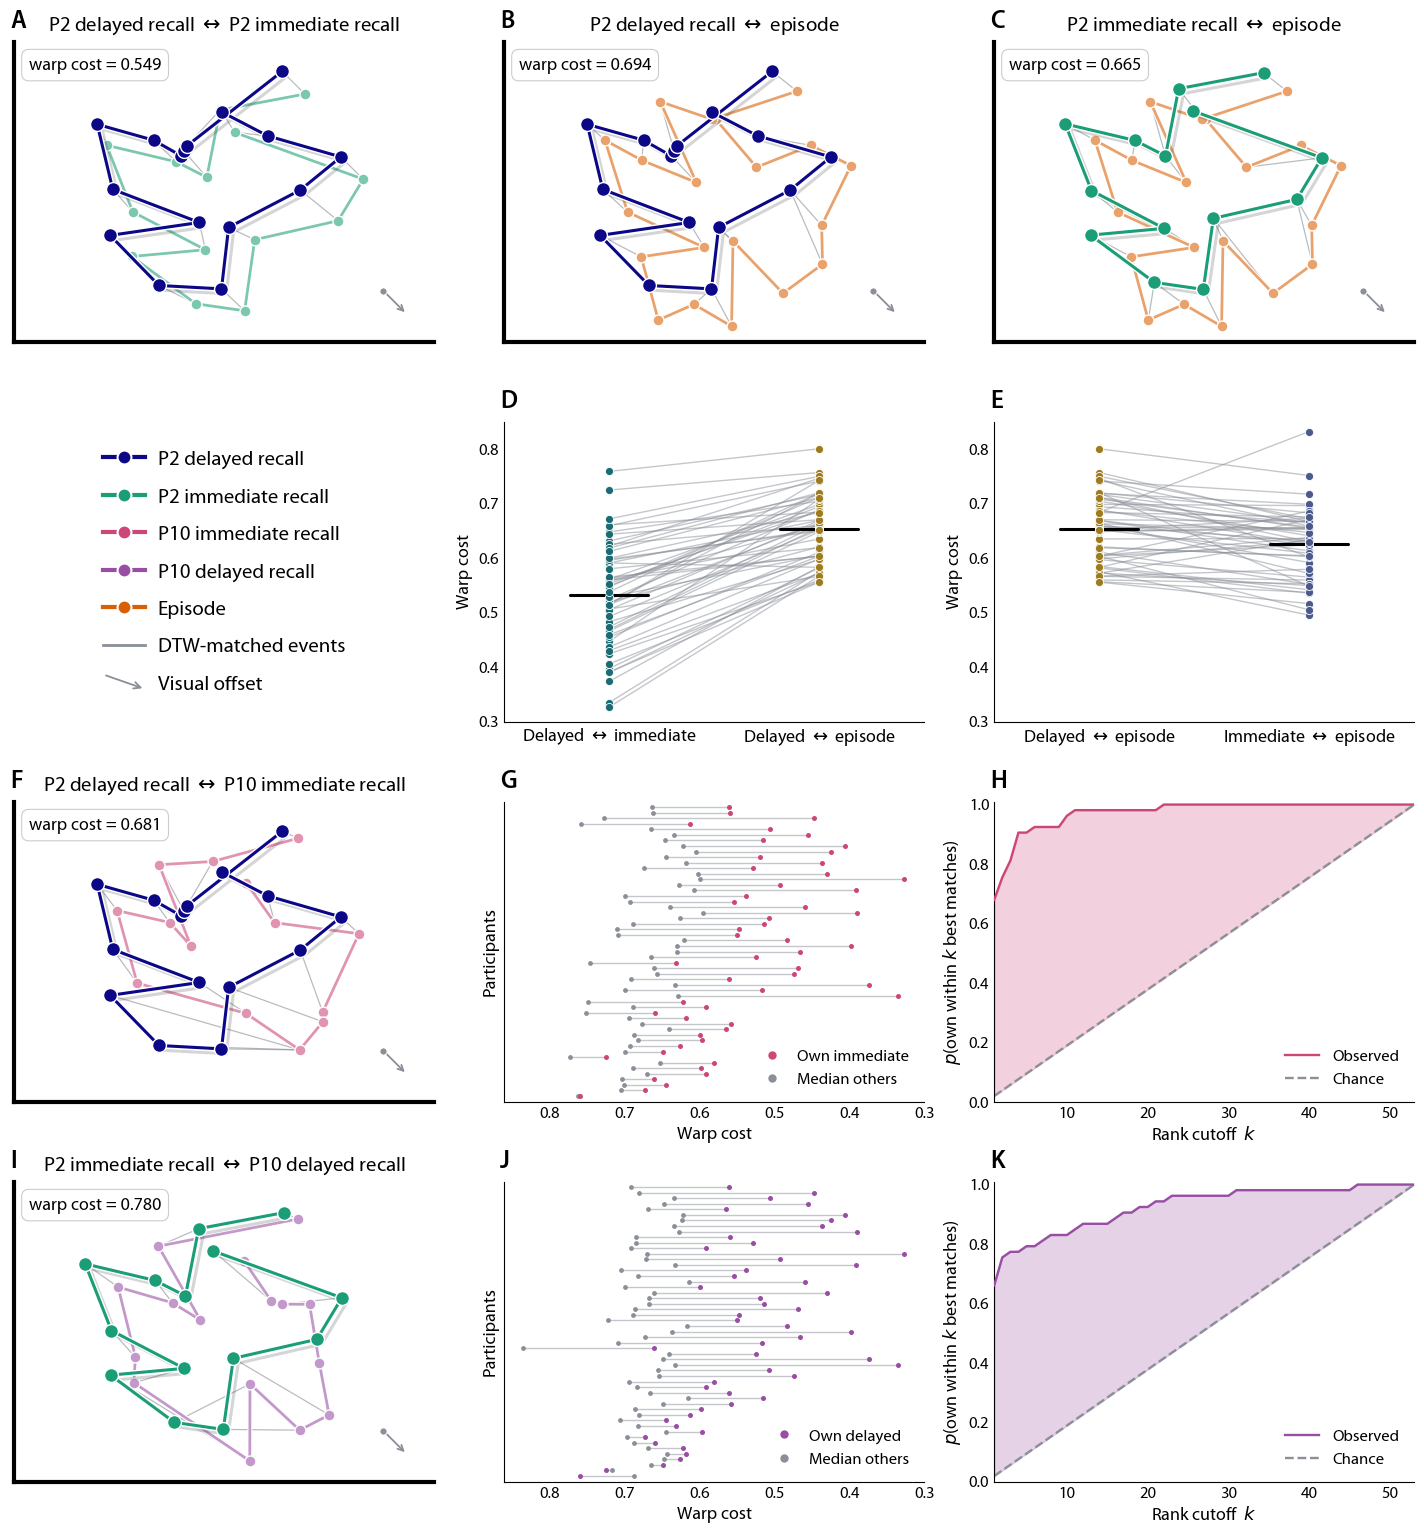

In [22]:
################################ CONFIG ################################

# =============================== SHARED ===============================

N_COLS = 3
N_ROWS = 4
CELL_ASPECT = 1.4
ROW_HEIGHT = 3.0
COL_WIDTH = CELL_ASPECT * ROW_HEIGHT
COL_GAP = 0.7
ROW_GAP = 0.8
QUANT_BOX_ASPECT = 1.0 / CELL_ASPECT

SURROGATE_COLOR = "#8a8f98"
CONNECTOR_COLOR = SURROGATE_COLOR
CONNECTOR_LW = 1.0
CONNECTOR_ALPHA = 0.5

PANEL_LETTER_FONTSIZE = 18
PANEL_LETTER_FONTWEIGHT = 'semibold'
PANEL_LETTER_POSITION = (-0.01, 1.03)
PANEL_LETTER_COLOR = 'k'

TICKLABEL_PAD = -2
RESULTS_TICKLABEL_FONTSIZE = 12
RESULTS_AXISLABEL_FONTSIZE = 13


# =========================== 2D TRAJECTORIES ==========================

MAIN_PARTICIPANT_N = 2
OTHER_PARTICIPANT_N = 10

MAIN_DELAYED_COLOR = "#0c0786"
MAIN_IMMEDIATE_COLOR = "#1B9E77"
OTHER_DELAYED_COLOR = "#984EA3"
OTHER_IMMEDIATE_COLOR = "#cc4778"
EPISODE_COLOR = "#D95F02"
WARP_LINE_COLOR = CONNECTOR_COLOR

EVENT_MARKERSIZE = 100
EVENT_BORDER_WIDTH = 1
PATH_LINEWIDTH = 2.2
PATH_CASING_WIDTH = PATH_LINEWIDTH + 2

WARP_LINEWIDTH = 0.9
WARP_LINE_ALPHA = 0.6

DEPTH_OFFSET = np.array([7.0, -7.0])
BACK_LIGHTEN = 0.42
BACK_LW_SCALE = 0.9
BACK_MARKER_SCALE = 0.62
BACK_CASING_EXTRA = 1.5
SHADOW_OFFSET = (3.5, -3.5)
SHADOW_COLOR = "#404040"
SHADOW_ALPHA = 0.22
SHOW_OFFSET_INDICATOR = True

OFFSET_INDICATOR_COLOR = CONNECTOR_COLOR
OFFSET_INDICATOR_ARROW_LW = 1.3
OFFSET_INDICATOR_ARROW_STYLE = '->'
OFFSET_INDICATOR_DOT_SIZE = 28
TRAJ_XLIM_PAD = 0
TRAJ_YLIM_PAD = 5
TRAJ_TITLE_FONTSIZE = 15
TRAJ_TITLE_PAD = 8

WARP_COST_BOX_X = 0.035
WARP_COST_BOX_Y = 0.95
WARP_COST_BOX_FONTSIZE = 13
WARP_COST_BBOX_STYLE = {
    'boxstyle': 'round,pad=0.4', 
    'fc': 'white', 
    'ec': '#cccccc', 
    'lw': 0.8
}

TRAJ_PANEL_SPINE_LINEWIDTH = 3


# =========================== SHARED LEGEND ============================

LEGEND_DOT_SIZE = 10
LEGEND_DOT_BORDER_WIDTH = 1.5
LEGEND_PATH_LINEWIDTH = 3
LEGEND_DTW_LINEWIDTH = 2
LEGEND_FONTSIZE = 15


# ============================ SLOPE PLOTS =============================

SLOPE_DOT_COLOR_DEL_IMM = "#1a6b73"
SLOPE_DOT_COLOR_DEL_EP = "#9e7b1e"
SLOPE_DOT_COLOR_IMM_EP = "#4a5a8c"
SLOPE_DOT_SIZE = 34
SLOPE_DOT_EDGE_W = 0.6

SLOPE_X = (0.15, 0.85)
SLOPE_XPAD = 0.35
SLOPE_YLIM = (0.3, 0.85)
MEAN_TICK_COLOR = "k"
MEAN_TICK_LW = 2.2
MEAN_TICK_HALFWIDTH = 0.13
SLOPE_E_YTICK_STEP = 0.1


# =========================== DUMBBELL PLOTS ===========================

DUMBBELL_MEDIAN_DOT_SIZE = 6
DUMBBELL_OWN_DOT_SIZE = 13
DUMBBELL_OWN_EDGE_W = 0
DUMBBELL_LEGEND_FONTSIZE = 12
DUMBBELL_LEGEND_MARKERSIZE = 5
DUMBBELL_XLIM = (0.3, 0.86)


# ============================ TOP-K CURVES ============================

TOPK_LINE_WIDTH = 1.7
TOPK_FILL_ALPHA = 0.25
CHANCE_LINE_WIDTH = 1.7
TOPK_LEGEND_FONTSIZE = 12


########################################################################


# =========================== derived values ===========================

main_participant = participants[MAIN_PARTICIPANT_N - 1]
other_participant = participants[OTHER_PARTICIPANT_N - 1]

# 2D trajectories
traj2d_main_del  = main_participant.paths_2d['delayed']
traj2d_main_imm  = main_participant.paths_2d['atlep1']
traj2d_other_imm = other_participant.paths_2d['atlep1']
traj2d_other_del = other_participant.paths_2d['delayed']
traj2d_episode = atlep1.path_2d

# warp costs and paths
events_maindel = del_events_centered[MAIN_PARTICIPANT_N - 1]
events_mainimm = imm_events_centered[MAIN_PARTICIPANT_N - 1]
events_otherdel = del_events_centered[OTHER_PARTICIPANT_N - 1]
events_otherimm = imm_events_centered[OTHER_PARTICIPANT_N - 1]
cost_maindel_mainimm, warp_maindel_mainimm = dtw(events_maindel, events_mainimm)
cost_maindel_ep, warp_maindel_ep = dtw(events_maindel, ep_events_centered)
cost_mainimm_ep, warp_mainimm_ep    = dtw(events_mainimm, ep_events_centered)
cost_maindel_otherimm, warp_maindel_otherimm = dtw(events_maindel, events_otherimm)
cost_otherdel_mainimm, warp_otherdel_mainimm = dtw(events_mainimm, events_otherdel)

# shared x,y-limits across panels, equal aspect padded to column width
_all_pts = np.vstack([traj2d_main_del, 
                      traj2d_main_imm, 
                      traj2d_other_imm, 
                      traj2d_other_del, 
                      traj2d_episode,
                      traj2d_main_del + DEPTH_OFFSET, 
                      traj2d_main_imm + DEPTH_OFFSET, 
                      traj2d_other_imm + DEPTH_OFFSET,
                      traj2d_other_del + DEPTH_OFFSET, 
                      traj2d_episode + DEPTH_OFFSET])
TRAJ2D_XMIN, TRAJ2D_YMIN = _all_pts.min(axis=0) - [TRAJ_XLIM_PAD, TRAJ_YLIM_PAD]
TRAJ2D_XMAX, TRAJ2D_YMAX = _all_pts.max(axis=0) + [TRAJ_XLIM_PAD, TRAJ_YLIM_PAD]
_x_center = 0.5 * (TRAJ2D_XMIN + TRAJ2D_XMAX)
_x_half = 0.5 * CELL_ASPECT * (TRAJ2D_YMAX - TRAJ2D_YMIN)
TRAJ2D_XMIN, TRAJ2D_XMAX = _x_center - _x_half, _x_center + _x_half


# =============================== LAYOUT ===============================
fig_width = N_COLS * COL_WIDTH + (N_COLS - 1) * COL_GAP
fig_height = N_ROWS * ROW_HEIGHT + (N_ROWS - 1) * ROW_GAP
fig = plt.figure(figsize=(fig_width, fig_height))
gs = fig.add_gridspec(N_ROWS, 
                      N_COLS, 
                      left=0,
                      right=1,
                      bottom=0,
                      top=1,
                      wspace=COL_GAP / COL_WIDTH, 
                      hspace=ROW_GAP / ROW_HEIGHT)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1], sharex=axA, sharey=axA)
axC = fig.add_subplot(gs[0, 2], sharex=axA, sharey=axA)

ax_legend = fig.add_subplot(gs[1, 0]); ax_legend.axis('off')
axD = fig.add_subplot(gs[1, 1])
axE = fig.add_subplot(gs[1, 2])

axF = fig.add_subplot(gs[2, 0], sharex=axA, sharey=axA)
axG = fig.add_subplot(gs[2, 1])
axH = fig.add_subplot(gs[2, 2])

axI = fig.add_subplot(gs[3, 0], sharex=axA, sharey=axA)
axJ = fig.add_subplot(gs[3, 1])
axK = fig.add_subplot(gs[3, 2])


# =========================== 2D TRAJECTORIES ==========================
title_A = (f'P{main_participant.sub_n} delayed recall $\\leftrightarrow$ '
           f'P{main_participant.sub_n} immediate recall')
title_B = f'P{main_participant.sub_n} delayed recall $\\leftrightarrow$ episode'
title_C = f'P{main_participant.sub_n} immediate recall $\\leftrightarrow$ episode'
title_F = (f'P{main_participant.sub_n} delayed recall $\\leftrightarrow$ '
           f'P{other_participant.sub_n} immediate recall')
title_I = (f'P{main_participant.sub_n} immediate recall $\\leftrightarrow$ '
           f'P{other_participant.sub_n} delayed recall')

draw_traj2d_panel(axA, 
                  traj2d_main_del, 
                  traj2d_main_imm, 
                  MAIN_DELAYED_COLOR, 
                  MAIN_IMMEDIATE_COLOR,
                  warp_maindel_mainimm,
                  cost_maindel_mainimm,
                  title_A)
draw_traj2d_panel(axB, 
                  traj2d_main_del, 
                  traj2d_episode, 
                  MAIN_DELAYED_COLOR, 
                  EPISODE_COLOR,
                  warp_maindel_ep,
                  cost_maindel_ep,
                  title_B)
draw_traj2d_panel(axC, 
                  traj2d_main_imm, 
                  traj2d_episode, 
                  MAIN_IMMEDIATE_COLOR, 
                  EPISODE_COLOR,
                  warp_mainimm_ep,
                  cost_mainimm_ep, 
                  title_C)
draw_traj2d_panel(axF, 
                  traj2d_main_del, 
                  traj2d_other_imm, 
                  MAIN_DELAYED_COLOR, 
                  OTHER_IMMEDIATE_COLOR,
                  warp_maindel_otherimm,
                  cost_maindel_otherimm, 
                  title_F)
draw_traj2d_panel(axI, 
                  traj2d_main_imm, 
                  traj2d_other_del, 
                  MAIN_IMMEDIATE_COLOR, 
                  OTHER_DELAYED_COLOR,
                  warp_otherdel_mainimm,
                  cost_otherdel_mainimm, 
                  title_I)

# =========================== SHARED LEGEND ============================

legend_entries = [
    (MAIN_DELAYED_COLOR, f'P{main_participant.sub_n} delayed recall'),
    (MAIN_IMMEDIATE_COLOR, f'P{main_participant.sub_n} immediate recall'),
    (OTHER_IMMEDIATE_COLOR, f'P{other_participant.sub_n} immediate recall'),
    (OTHER_DELAYED_COLOR, f'P{other_participant.sub_n} delayed recall'),
    (EPISODE_COLOR, 'Episode')
]
legend_handles = []
for (color, label) in legend_entries:
    handle = Line2D([0], 
                    [0], 
                    color=color, 
                    marker='o', 
                    markerfacecolor=color,
                    markeredgecolor='white', 
                    markeredgewidth=LEGEND_DOT_BORDER_WIDTH, 
                    markersize=LEGEND_DOT_SIZE,
                    lw=LEGEND_PATH_LINEWIDTH, 
                    label=label)
    legend_handles.append(handle)
    
dtw_handle = Line2D([0], 
                    [0], 
                    color=WARP_LINE_COLOR, 
                    lw=LEGEND_DTW_LINEWIDTH, 
                    label='DTW-matched events')
# placeholder arrow for simplicity, will replace with exact indicator 
# arrow in Illustrator
offset_placeholder_handle = FancyArrowPatch((0, 0), 
                                            (1, 0), 
                                            arrowstyle='-|>', 
                                            mutation_scale=12,
                                            color=OFFSET_INDICATOR_COLOR, 
                                            lw=OFFSET_INDICATOR_ARROW_LW, 
                                            label='Visual offset')
legend_handles.extend([dtw_handle, offset_placeholder_handle])

ax_legend.legend(handles=legend_handles, 
                 loc='center', 
                 ncol=1, 
                 frameon=False,
                 fontsize=LEGEND_FONTSIZE, 
                 handletextpad=0.6, 
                 labelspacing=0.9,
                 handler_map={FancyArrowPatch: _HandlerArrow()})


# ============================ SLOPE PLOTS =============================

draw_slope_panel(axD, 
                 warp_dists_del_imm, 
                 warp_dists_del_episode, 
                 SLOPE_DOT_COLOR_DEL_IMM, 
                 SLOPE_DOT_COLOR_DEL_EP,
                 'Delayed $\\leftrightarrow$ immediate', 
                 'Delayed $\\leftrightarrow$ episode')
draw_slope_panel(axE, 
                 warp_dists_del_episode, 
                 warp_dists_imm_episode, 
                 SLOPE_DOT_COLOR_DEL_EP, 
                 SLOPE_DOT_COLOR_IMM_EP,
                 'Delayed $\\leftrightarrow$ episode', 
                 'Immediate $\\leftrightarrow$ episode')


# =========================== DUMBBELL PLOTS ===========================

fwd_dumbbell_order = np.argsort(-pct_ranks_fwd)
draw_dumbbell_panel(axG, 
                    warp_dists_del_imm, 
                    warp_dists_others_fwd, 
                    fwd_dumbbell_order, 
                    'Own immediate', 
                    OTHER_IMMEDIATE_COLOR)

rev_dumbbell_order = np.argsort(-pct_ranks_rev)
draw_dumbbell_panel(axJ, 
                    warp_dists_del_imm, 
                    warp_dists_others_rev, 
                    rev_dumbbell_order, 
                    'Own delayed', 
                    OTHER_DELAYED_COLOR)


# ============================ TOP-K CURVES ============================

draw_topk_panel(axH, 
                warp_dists_del_imm, 
                warp_dists_others_fwd, 
                OTHER_IMMEDIATE_COLOR)
draw_topk_panel(axK, 
                warp_dists_del_imm, 
                warp_dists_others_rev, 
                OTHER_DELAYED_COLOR)


# =========================== PANEL LETTERS ============================ 

letter_ix = 0
for ax in fig.axes:
    if ax is ax_legend:
        continue
        
    add_panel_letter(ax, string.ascii_uppercase[letter_ix])
    letter_ix += 1
    

# ======================== STYLING ADJUSTMENTS =========================
    
for ax in (axA, axB, axC, axF, axI):
    ax.spines[['left', 'bottom']].set_linewidth(TRAJ_PANEL_SPINE_LINEWIDTH)
    
for ax in (axD, axE, axG, axH, axJ, axK):
    ax.tick_params(axis='both', length=0, labelsize=RESULTS_TICKLABEL_FONTSIZE)
    ax.xaxis.label.set_fontsize(RESULTS_AXISLABEL_FONTSIZE)
    ax.yaxis.label.set_fontsize(RESULTS_AXISLABEL_FONTSIZE)
    
for ax in (axD, axE):
    ax.tick_params(axis='x', labelsize=RESULTS_AXISLABEL_FONTSIZE)   
    

# plt.savefig(FIG_DIR / 'dtw-figure.pdf', bbox_inches='tight')
plt.show()